<a href="https://colab.research.google.com/github/spencer18001/Practical-Deep-Learning/blob/main/note_pca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Principal Component Analysis (PCA)

參考:
- [Principal Component Analysis and Autoencoders](https://people.tamu.edu/~sji/classes/PCA.pdf)

PCA
- feature (dimensionality) reduction
- project the high-dimensional features to a lower-dimensional space with maximal variance and minimum reconstruction error simultaneously

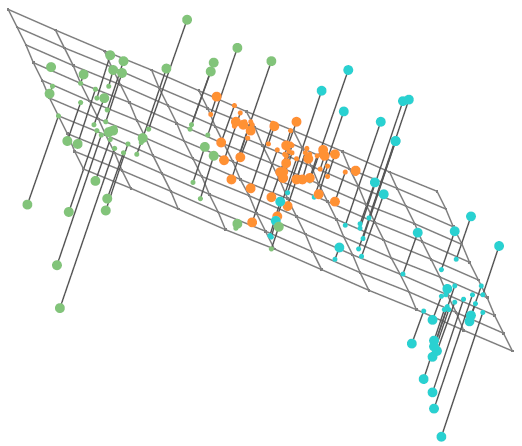

#### maximal variance

projects the features to a 1-dimensional space (降維投影)
- features $x_1,\dots,x_n \in \mathbb{R}^p$
- projection $a \in \mathbb{R}^p,\ a^Tx_i=z_i \in \mathbb{R}$
- solve $a^*=\mathop{\arg\max}\limits_{\|a\| = 1} \frac{1}{n} \sum_{i=1}^n (z_i-\bar{z})^2 \quad \text {(variance of the reduced data)}$


- $\bar{z}=\frac{1}{n}\sum_{i=1}^n z_i=\frac{1}{n}\sum_{i=1}^n a^Tx_i=a^T \left( \frac{1}{n}\sum_{i=1}^n x_i \right)=a^T\bar{x}$
- $\begin{align*}
a^*
&= \mathop{\arg\max}\limits_{\|a\| = 1} \frac{1}{n} \sum_{i=1}^n (z_i - \bar{z})^2 \\
&= \mathop{\arg\max}\limits_{\|a\| = 1} \frac{1}{n} \sum_{i=1}^n (a^T x_i - a^T \bar{x})^2 \\
&= \mathop{\arg\max}\limits_{\|a\| = 1} \frac{1}{n} \sum_{i=1}^n a^T (x_i - \bar{x})(x_i - \bar{x})^T a \\
&= \mathop{\arg\max}\limits_{\|a\| = 1} a^T \left( \frac{1}{n} \sum_{i=1}^n (x_i - \bar{x})(x_i - \bar{x})^T \right) a \\
&= \mathop{\arg\max}\limits_{\|a\| = 1} a^T C a
\end{align*}$
  - covariance matrix: $C=\left( \frac{1}{n} \sum_{i=1}^n (x_i - \bar{x})(x_i - \bar{x})^T \right)$
  - variance in a particular direction ($u$): $V_u=u \cdot (Cu) \quad \text{where}\ \|u\| = 1 \quad$ ([參考](https://math.libretexts.org/Bookshelves/Linear_Algebra/Understanding_Linear_Algebra_(Austin)/07%3A_The_Spectral_Theorem_and_singular_value_decompositions/7.02%3A_Quadratic_forms))
    - statictical proof: $U=\sum_{i=1}^n a_iY_i \implies V(U)=\sum_{i=1}^n a_i^2V(Y_i)+2\sum\sum_{1 \le i \lt j \le n} a_ia_jCov(Y_i,Y_j)$

projects the features to a $k$-dimensional space
- $A^*=\mathop{\arg\max}\limits_{A \in \mathbb{R}^{p \times k}:A^TA=I_k} \mathrm{tr}(A^TCA)$
  - $\mathrm{tr}(A^TCA)=\sum_{i=1}^k \left( a_i^TCa_i \right) \quad \text{where}\ A=[a_1,\dots,a_k]$

*Ky Fan Theorem*

Let
- symmetric matrix $H \in \mathbb{R}^{p \times p}$
- eigenvalues $\lambda_1 \ge \dots \ge \lambda_p$
- corresponding (orthonormal) eigenvectors $u_1,\dots,u_p$
- arbitrary orthogonal matrix $Q$

Then
- $\max\limits_{A \in \mathbb{R}^{p \times k}:A^TA=I_k} \mathrm{tr}(A^THA)=\lambda_1+\dots+\lambda_k$
- optimal $A^*=[u_1,\dots,u_k]Q$

#### PCA computation

- $X=[x_1,\dots,x_n] \in \mathbb{R}^{p \times n}$
- $\bar{X}=\frac{1}{n}X1_n \in \mathbb{R}^{p \times 1}$
- $\tilde{X}=(X-\bar{X}1_n^T) \in \mathbb{R}^{p \times n} \quad$ (centered $X$)

- PCA: $\tilde{X}=U\tilde{\Sigma}V^T \implies $ projection matrix (principal axes) $U_{:,k} \in \mathbb{R}^{p \times k}$
- projected features: $U_{:,k}^T \tilde{X}=Z \in \mathbb{R}^{k \times n}$
- $k$-th principal components (PC): $Z_{k,:}$

#### minimum reconstruction error

- reconstruction process: $\hat{X}=U_{:,k}Z=U_{:,k} U_{:,k}^T \tilde{X} \quad$ (還原維度)
- reconstruction error: $\|\tilde{X}-\hat{X}\|_F=\|\tilde{X}-U_{:,k}U_{:,k}^T\tilde{X}\|_F$

*Theorem*

Let
- SVD: $R=U \tilde{\Sigma} V^T$
- truncated SVD: $R_k=U_{:,k} \Sigma_{:,k} V_{:,k}^T=\sum_{i=1}^k\sigma_i u_i v_i^T$

Then
- $R_k$ is the best rank-$k$ approximation to $R$
- $\min\limits_{B:rank(B) \le k} \|R-B\|_F = \|R-R_k\|_F=\sqrt{\sum_{i=k+1}^n}\sigma_i^2$

- $\begin{align*}
U_{:,k}U_{:,k}^T\tilde{X}&=U_{:,:k}U_{:,:k}^TU\tilde{\Sigma}V^T \\
&=U_{:,:k}U_{:,:k}^T[U_{:,:k} \quad U_{:,k:}^T]\tilde{\Sigma}V^T \\
&=U_{:,:k}[I \quad 0]\tilde{\Sigma}V^T \\
&=[U_{:,:k} \quad 0]\tilde{\Sigma}V^T \\
&=U_{:,:k}\Sigma_{:,:k}V_{:,:k}^T \quad (\text{truncated SVD of}\ \tilde{X})
\end{align*}$
- $\mathop{\arg\min}\limits_{B:\text {rank}(B) \le k} \|\tilde{X}-B\|_F=U_{:,k}U_{:,k}^T\tilde{X}=\hat{X}$

#### PCA as Autoencoders

autoencoder:

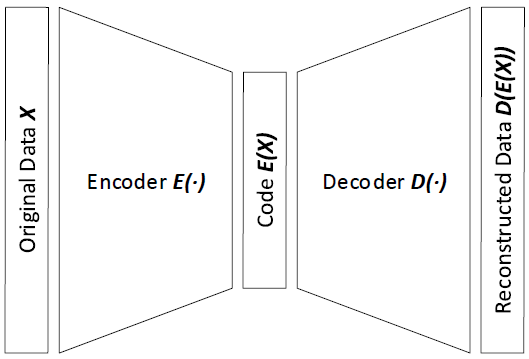

Consider a special autoencoder
- $W \in \mathbb{R}^{p \times k}$
- $E(\tilde{X})=W^T\tilde{X} \in \mathbb{R}^{k \times n}$
- $D(E(\tilde{X}))=WE(\tilde{X})=WW^T\tilde{X} \in \mathbb{R}^{p \times n}$

objective:
- $\min\limits_{W:rank(WW^T\tilde{X}) \le k} \|\tilde{X}-WW^T\tilde{X}\|_F$

$\implies$
- $W=U_{:,k}$